# EDA and Visualizations

**Goal:** Understand customers clearly using simple visuals: who they are, what they spend on, which campaigns worked, and which channels they prefer.

The questions we will answer:
1. Who is our typical customer? (Demographics)
2. Which campaigns performed best?
3. What do customers spend on?
4. Which channel do they prefer to buy from?
5. What separates a customer who responds from one who doesn't?
6. Does loyalty (how long they've been with us) affect response?

In [1]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') #pandas and seaborn somethimes throuw harmless verison warnings . 

In [2]:
#Clean visual systle no cluster 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

In [3]:
#load the clean dataset 

data =pd.read_csv("../data/marketing_campaign_clean.csv")
data.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Days_Customer,Total_Spend,Total_Purchases,Total_Campaigns_Accepted,Has_Children
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,1,67,4867,1617,25,0,0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,70,4317,27,6,0,1
2,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,40,4343,53,8,0,1
3,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,43,4365,422,19,0,1
4,Graduation,Divorced,55635.0,0,1,34,235,65,164,50,...,0,0,0,0,53,4797,590,21,0,1


# 1. Who is Our Typical Customer?
- `Age`: How old are they?
- `Income`: How much do they earn?
- `Education`: What is their education level?
- `Marital_Status`: What is their family status?

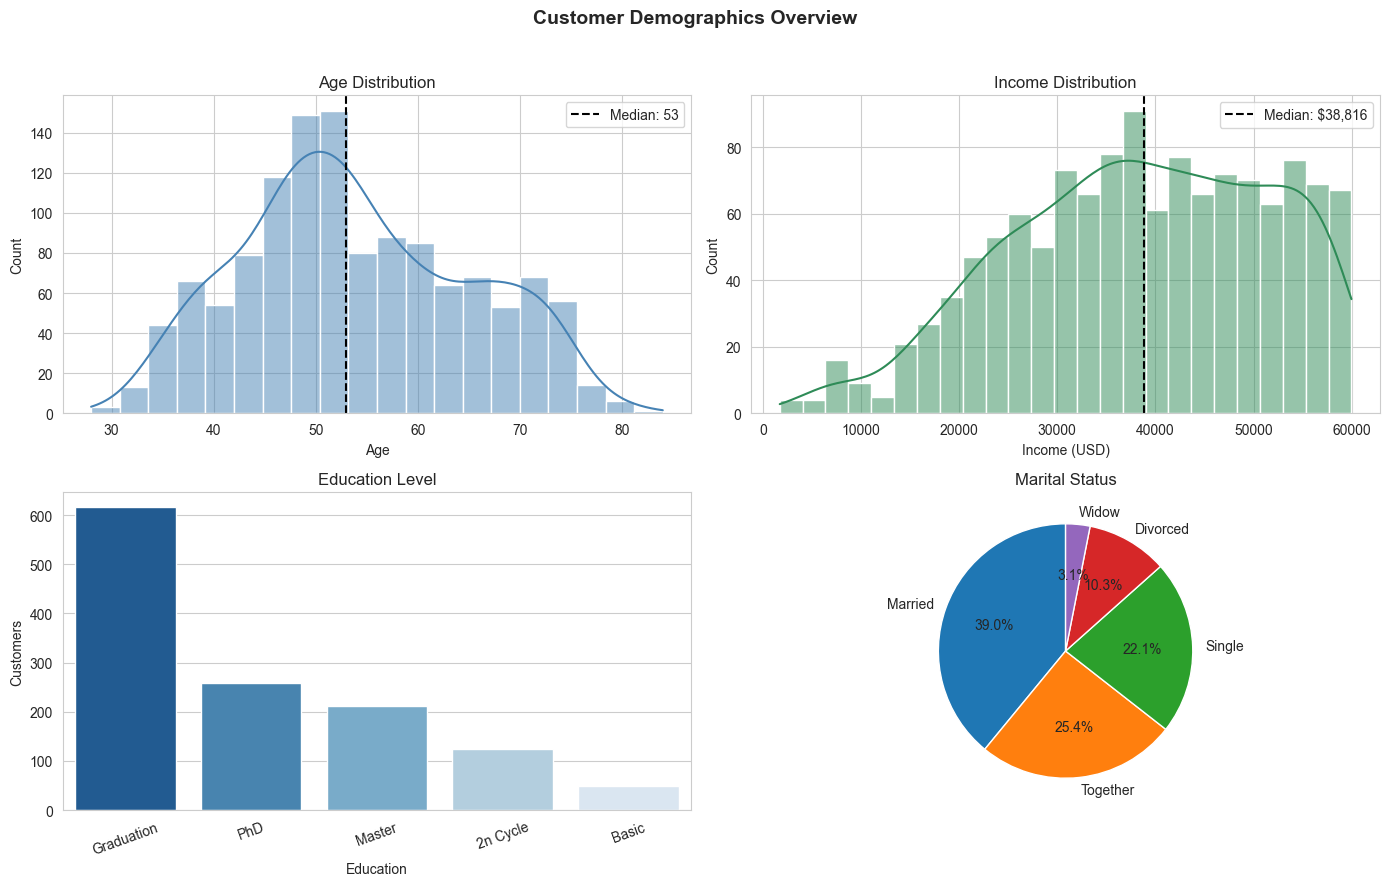

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Customer Demographics Overview", fontsize=14, fontweight="bold")

# 1) Age distribution
sns.histplot(data=data, x="Age", bins=20, kde=True, color="steelblue", ax=axes[0, 0])
axes[0, 0].axvline(data["Age"].median(), color="black", linestyle="--", label=f"Median: {data['Age'].median():.0f}")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# 2) Income distribution
sns.histplot(data=data, x="Income", bins=25, kde=True, color="seagreen", ax=axes[0, 1])
axes[0, 1].axvline(data["Income"].median(), color="black", linestyle="--", label=f"Median: ${data['Income'].median():,.0f}")
axes[0, 1].set_title("Income Distribution")
axes[0, 1].set_xlabel("Income (USD)")
axes[0, 1].legend()

# 3) Education split
edu_counts = data["Education"].value_counts()
sns.barplot(x=edu_counts.index, y=edu_counts.values, palette="Blues_r", ax=axes[1, 0])
axes[1, 0].set_title("Education Level")
axes[1, 0].set_xlabel("Education")
axes[1, 0].set_ylabel("Customers")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4) Marital status split
marital_counts = data["Marital_Status"].value_counts()
axes[1, 1].pie(marital_counts.values, labels=marital_counts.index, autopct="%1.1f%%", startangle=90)
axes[1, 1].set_title("Marital Status")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Insights from Figure 1 (Demographics)
- Median customer age is about **53 years**: this is a mature customer base.
- Median income is about **$38.8K**: focus on value-for-money messaging.
- Most customers are **Graduates**, then **PhD/Master**: clear and informative copy works best.
- Around **64% are Married/Together**: family-oriented offers can perform better.

# 2. Which Campaigns Performed Best?


We compare acceptance rates for 5 campaigns plus the final offer (`Response`).

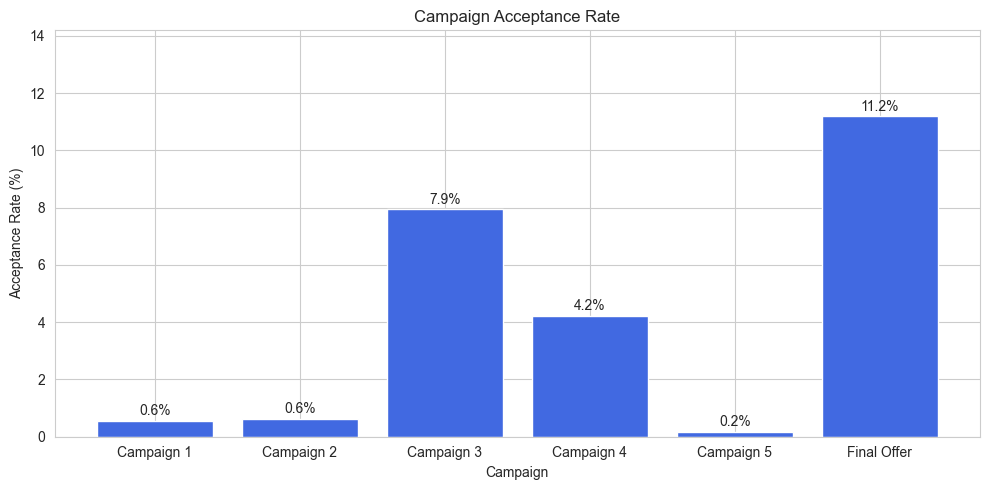

In [5]:
# ── Question: Which campaign got the best response? ──

# Calculate acceptance rate for each campaign
camp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5', 'Response']
camp_labels = ['Campaign 1', 'Campaign 2', 'Campaign 3',
            'Campaign 4', 'Campaign 5', 'Final Offer']

acceptance_rate = data[camp_cols].mean().mul(100).round(2)

plt.figure(figsize=(10, 5))
bars = plt.bar(camp_labels, acceptance_rate.values, color="royalblue", edgecolor="white")

# Add percentage label on top of each bar
for bar, value in zip(bars, acceptance_rate.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.2, f"{value:.1f}%", ha="center", fontsize=10)

plt.title("Campaign Acceptance Rate")
plt.xlabel("Campaign")
plt.ylabel("Acceptance Rate (%)")
plt.ylim(0, max(acceptance_rate.values) + 3)
plt.tight_layout()
plt.show()

## Insights from Figure 2 (Campaign Acceptance Rate)
- The **Final Offer (~11.2%)** is the strongest performer.
- **Campaign 3 (~7.9%)** and **Campaign 4 (~4.2%)** are moderate performers.
- **Campaign 1/2/5 (<1%)** are weak and should be redesigned (audience, timing, message). 

# 3. How Many Campaigns Did Each Customer Accept?

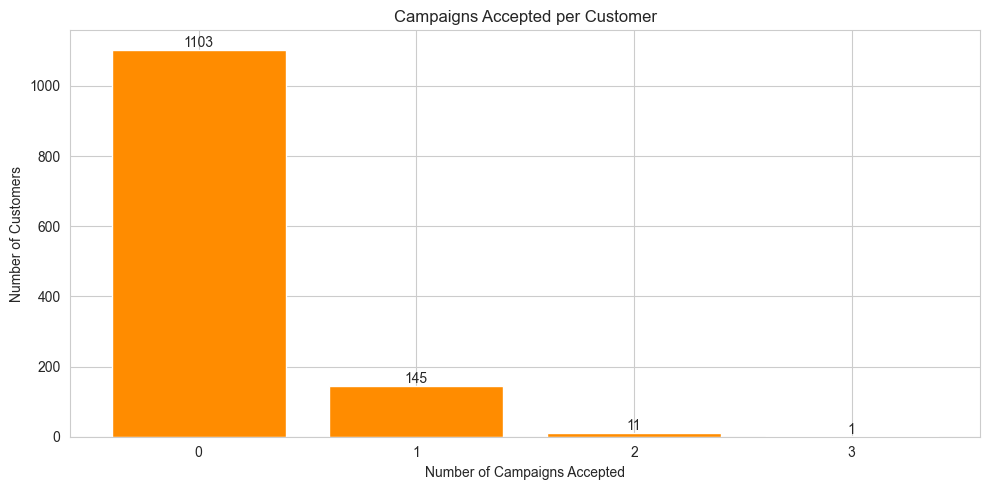

In [24]:
# Are customers accepting one campaign or many?
campaign_counts = data["Total_Campaigns_Accepted"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(campaign_counts.index, campaign_counts.values, color="darkorange", edgecolor="white")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8, f"{int(bar.get_height())}", ha="center", fontsize=10)

plt.title("Campaigns Accepted per Customer")
plt.xlabel("Number of Campaigns Accepted")
plt.ylabel("Number of Customers")
plt.xticks(campaign_counts.index)
plt.savefig("../Figures/campagins accepted per customer")
plt.tight_layout()
plt.show()

This chart shows distribution of `Total_Campaigns_Accepted` for each customer.

## Insights from Figure 3 (Campaigns Accepted per Customer)
- Most customers (**1103**) accepted **0 campaigns**.
- A smaller group (**145**) accepted **1 campaign**.
- Very few accepted **2+ campaigns** (highly engaged segment).
- Use targeted retention offers for this high-response micro-segment.

# 4. What Do Customers Spend On?


In [7]:
data.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Age', 'Days_Customer', 'Total_Spend',
       'Total_Purchases', 'Total_Campaigns_Accepted', 'Has_Children'],
      dtype='object')

We compare average spending across 6 product categories.

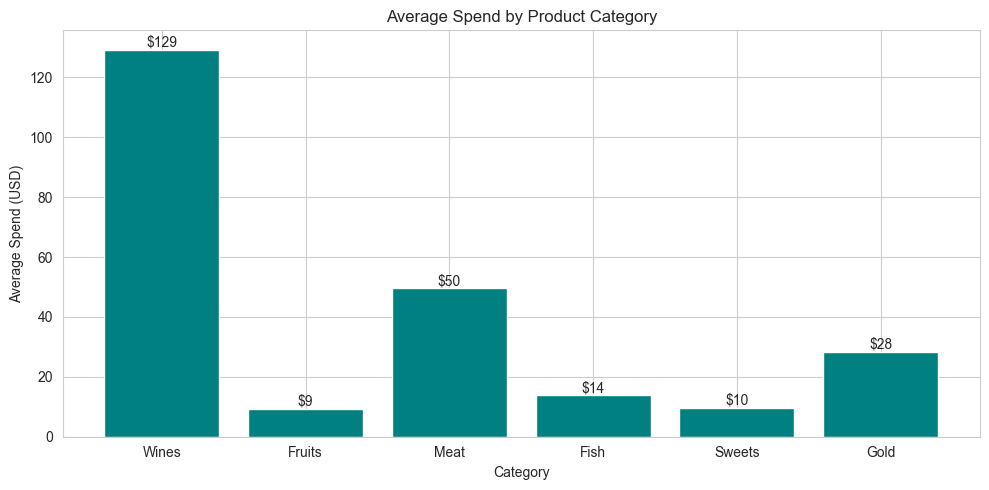

In [23]:
#  Which product makes the most money? ──

spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
labels = ["Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold"]

avg_spend = data[spend_cols].mean().values

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, avg_spend, color="teal", edgecolor="white")

# Add dollar label on top of each bar
for bar, value in zip(bars, avg_spend):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 1, f"${value:.0f}", ha="center", fontsize=10)

plt.title("Average Spend by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Spend (USD)")
plt.savefig("../Figures/Average spend by prouduct category")
plt.tight_layout()
plt.show()

## Insights from Figure 4 (Product Spend)
- **Wines** are the top category by a large margin (~$129 average spend).
- **Meat** is second (~$50), while other categories are much lower.
- Wine-focused bundles and premium cross-sell can increase revenue.

# 5. Which Channel Do Customers Prefer?


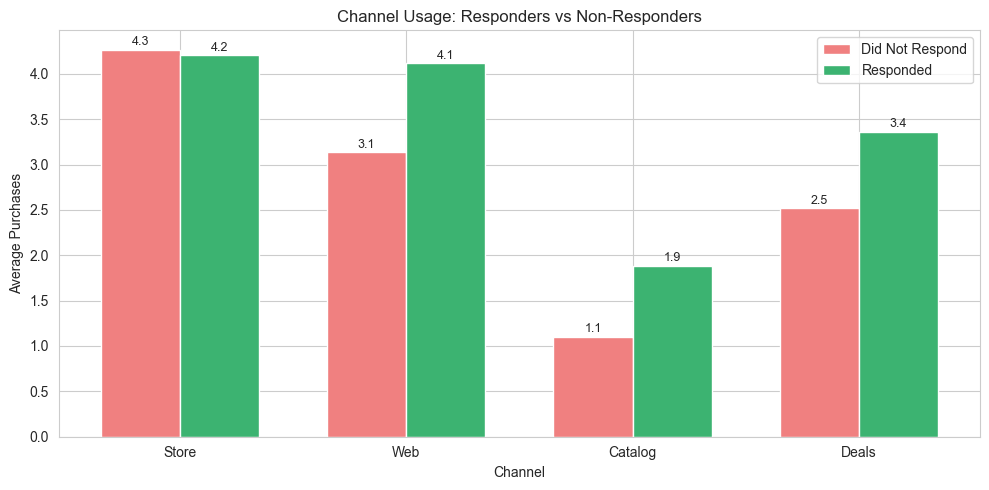

In [21]:
# ── Question: Do responders shop differently by channel? ──

channel_cols = ["NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases", "NumDealsPurchases"]
channel_labels = ["Store", "Web", "Catalog", "Deals"]

# Average purchases by response group
responders = data[data["Response"] == 1][channel_cols].mean()
non_responders = data[data["Response"] == 0][channel_cols].mean()

x = np.arange(len(channel_labels))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width / 2, non_responders.values, width,
                label="Did Not Respond", color="lightcoral", edgecolor="white")
bars2 = plt.bar(x + width / 2, responders.values, width,
                label="Responded", color="mediumseagreen", edgecolor="white")

for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f"{bar.get_height():.1f}",
             ha="center", fontsize=9)

plt.title("Channel Usage: Responders vs Non-Responders")
plt.xlabel("Channel")
plt.ylabel("Average Purchases")
plt.xticks(x, channel_labels)
plt.legend()
plt.savefig("../Figures/Channel usge thorugh responders vs non responders")
plt.tight_layout()
plt.show()

## Insights from Figure 5 (Channel by Response)
- Responders use **Web** and **Catalog** more than non-responders.
- Store purchases are similar in both groups.
- Responders also buy more through **Deals**, indicating offer-sensitivity.
- Prioritize digital + personalized offer campaigns for likely responders.

# 6. Which Customer Segments Respond More?

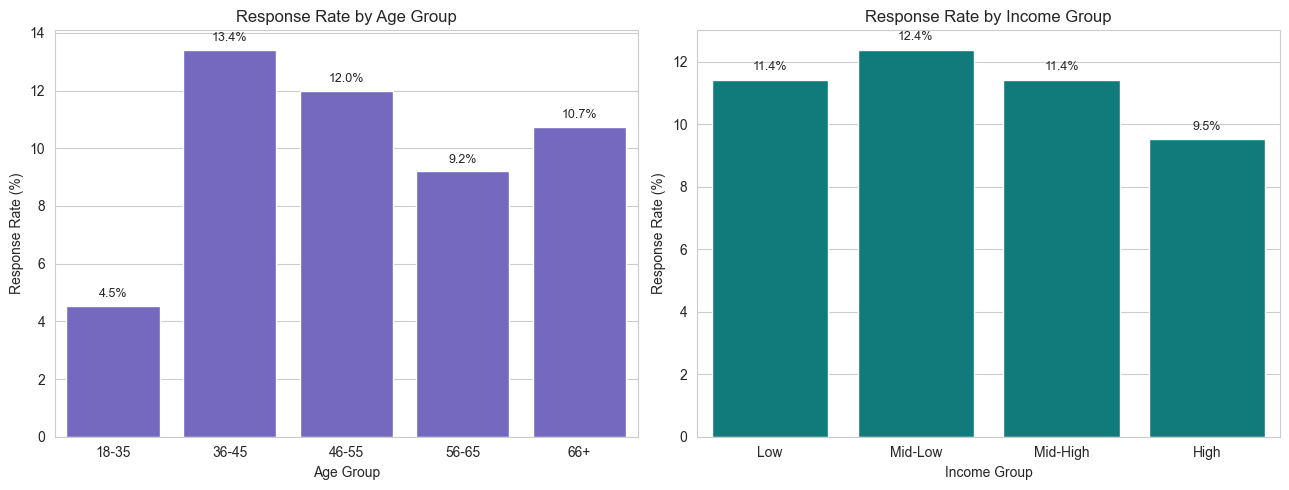

In [ ]:
# Figure 6: Response rate by age group and income group
segment_df = data.copy()

segment_df["Age_Group"] = pd.cut(
    segment_df["Age"],
    bins=[18, 35, 45, 55, 65, 100],
    labels=["18-35", "36-45", "46-55", "56-65", "66+"]
)

segment_df["Income_Group"] = pd.qcut(
    segment_df["Income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

age_response = segment_df.groupby("Age_Group")["Response"].mean().mul(100)
income_response = segment_df.groupby("Income_Group")["Response"].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=age_response.index, y=age_response.values, color="slateblue", ax=axes[0])
axes[0].set_title("Response Rate by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Response Rate (%)")

for i, v in enumerate(age_response.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

sns.barplot(x=income_response.index, y=income_response.values, color="darkcyan", ax=axes[1])
axes[1].set_title("Response Rate by Income Group")
axes[1].set_xlabel("Income Group")
axes[1].set_ylabel("Response Rate (%)")

for i, v in enumerate(income_response.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../Figures/Response rate by age group and income group")
plt.show()

## Insights from Figure 6 (Segment Response)
- Response rate changes by age group, so age-based targeting is useful.
- Higher income groups usually show better acceptance than lower income groups.
- Build separate campaign creatives for high-response segments and low-response segments.

# 7. Do Responders Spend More?

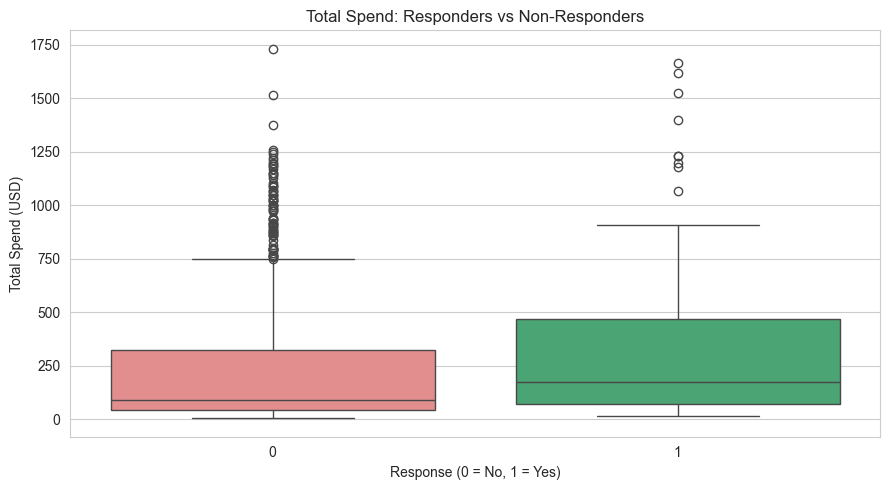

In [19]:
# Figure 7: Total spend distribution by response
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="Response", y="Total_Spend", palette=["lightcoral", "mediumseagreen"])

plt.title("Total Spend: Responders vs Non-Responders")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Total Spend (USD)")
plt.tight_layout()
plt.savefig("../Figures/Total spend by responders and non responders")
plt.show()

## Insights from Figure 7 (Spend vs Response)
- Responders generally spend more than non-responders.
- High-spend customers are a strong target for premium campaign offers.
- Use spend-based segmentation before sending costly promotions.

# 8. Does Recency Affect Response?

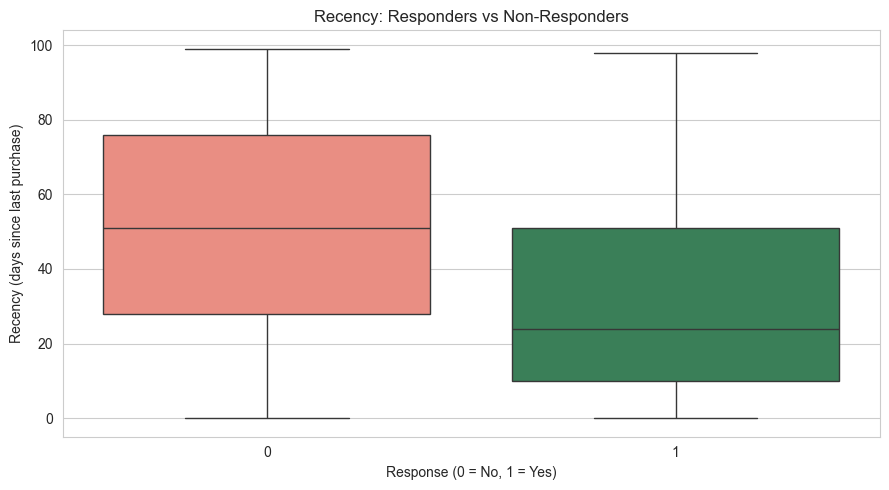

In [18]:
# Figure 8: Recency by response group
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="Response", y="Recency", palette=["salmon", "seagreen"])

plt.title("Recency: Responders vs Non-Responders")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Recency (days since last purchase)")
plt.tight_layout()
plt.savefig("../Figures/Responders VS non-responders")
plt.show()

## Insights from Figure 8 (Recency vs Response)
- If responders have lower recency, active customers are easier to convert.
- If recency is high, win-back campaigns become important.
- Trigger campaigns based on inactivity windows (for example 30, 60, 90 days).

# 9. Does Customer Loyalty (Tenure) Affect Response?

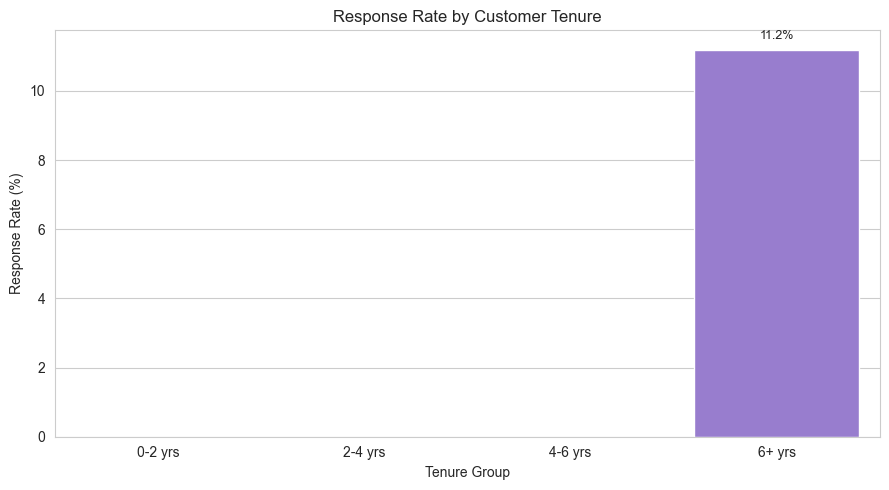

In [14]:
# Figure 9: Response rate by customer tenure
loyalty_df = data.copy()

loyalty_df["Tenure_Years"] = loyalty_df["Days_Customer"] / 365
loyalty_df["Tenure_Group"] = pd.cut(
    loyalty_df["Tenure_Years"],
    bins=[0, 2, 4, 6, 20],
    labels=["0-2 yrs", "2-4 yrs", "4-6 yrs", "6+ yrs"]
)

tenure_response = loyalty_df.groupby("Tenure_Group")["Response"].mean().mul(100)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=tenure_response.index, y=tenure_response.values, color="mediumpurple")

for i, v in enumerate(tenure_response.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.title("Response Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.savefig("../Figures/Response Rate by customer tenure")
plt.ylabel("Response Rate (%)")
plt.tight_layout()
plt.show()

## Insights from Figure 9 (Loyalty vs Response)
- Tenure groups help identify who is easiest to convert.
- If longer-tenure users respond more, loyalty campaigns should be prioritized.
- If newer users respond better, focus on onboarding and early-life offers.